### Homework: LLM Architectures, Scaling Laws, and Training Data

#### Instructions:
- Complete the following exercises based on the lecture material.
- Submit your completed notebook with all cells executed.

---

## Part 1: LLM Architecture Variants

### Question 1: Understanding LLM Architectures
**(a)** Compare and contrast decoder-only, encoder-decoder, and mixture-of-experts (MoE) architectures in large language models.

- Encoder only models produce context embeddings from the input and are good for understanding tasks such as classification.
- Decoder only models are optimal for generating the next token based on the input sequence.
- Encoder and decoder only models are more efficient to train compared to encoder-decoder models.
- Encoder-decoder models are the most computationally intensive architectures to train, but are ideal for sequence to sequence tasks such as translation where the model must identify relationships in the input and produce an output.
- MoE architectures only activate a sub-set of the parameters per input, improving the computational efficiency of the model while maintaining similar capabilities. MoE models are more challenging to train and deploy compared to monolithic models.

**(b)** What are the advantages of using sparse attention mechanisms in LLMs?

- Sparse attention enables more efficient inference by reducing how many tokens the model attends to for each input. This has a significant impact on the time and memory complexity of the attention mechanism.
- By reducing computational demands, sparse attention makes training and inference with longer contexts feasible.

### Question 2: Implementing Different LLM Architectures
Modify the given function to implement a decoder-only Transformer and test it on dummy input.


In [2]:
import torch
import torch.nn as nn

class DecoderOnlyTransformer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerDecoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=d_ff)
            for _ in range(num_layers)
        ])
        self.ln = nn.LayerNorm(d_model)
        # final linear projection
        self.linear = nn.Linear(d_model, d_ff)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x, x)
        x = self.ln(x)
        # apply final linear projection
        return self.linear(x)

# Test with dummy input
decoder = DecoderOnlyTransformer(64, 8, 256, 3)
x = torch.rand(10, 32, 64)
out = decoder(x)
print(out.shape)

torch.Size([10, 32, 256])


Modify the code to include a final linear projection layer.

---

## Part 2: Scaling Laws in Training LLMs

### Question 3: Understanding Scaling Laws
**(a)** Define and explain the three key factors in LLM scaling laws: compute, data, and model size. How do they interact?

- Model size is the number of parameters in the model, data is the number of tokens of data used to train the model, and compute is the budget for computational resources used to train the model.
- The three factors must be balanced in order to improve the model's performance without wasting resources.
- For a given compute budget, there is an optimal model size to avoid wasting resources during training.
- When the model size increases, the amount of training data must also be increased to avoid overfitting. But, loss also decreases when the model size increases. If the model size is increased without increasing the compute budget, then the model may end up undertrained.
- Increasing data generally improves performance, but competes with the model size at a given compute budget.

**(b)** Given the following dataset sizes and compute budgets, predict which model configurations would be optimal:

| Compute (FLOPs) | Data Tokens | Model Parameters |
|----------------|------------|-----------------|
| 1e19          | 1e12       | 10B            |
| 1e21          | 1e14       | *2.9B*              |

Calculate the missing model parameter size assuming Chinchilla scaling laws.

- Under Chinchilla scaling laws, increasing the training tokens while decreasing model parameters will optimize performance at a given compute budget
- N=\sqrt{1e21/120}=2.9x10^9

### Question 4: Experimenting with Scaling Effects
Modify the given script to train a simple LLM with different scaling parameters and compare the loss trends.

Model size 128: Final loss = 0.1829967498779297
Model size 256: Final loss = 0.05548824742436409
Model size 512: Final loss = 0.04562824219465256


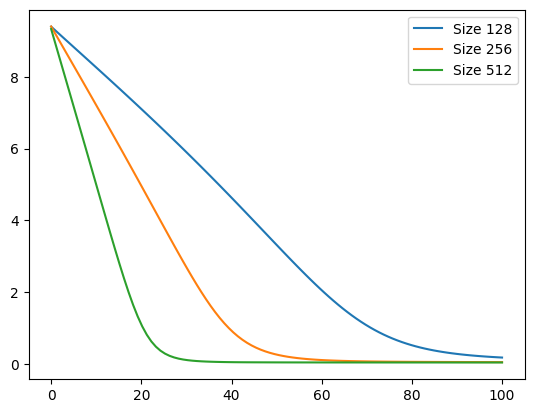

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

class SimpleLLM(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model)
        self.ln = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        x = self.ln(x)
        return self.fc(x)

# Train with different model sizes
vocab_size = 10000
models = [SimpleLLM(d_model, vocab_size) for d_model in [128, 256, 512]]
# Track losses for each model size
all_losses = []

for model in models:
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    dummy_input = torch.randint(0, vocab_size, (32, 20))
    dummy_target = torch.randint(0, vocab_size, (32, 20))
    # Track losses for each training iteration
    losses = []

    for _ in range(100):  # Simulate training
        optimizer.zero_grad()
        output = model(dummy_input)
        loss = loss_fn(output.view(-1, vocab_size), dummy_target.view(-1))
        losses.append(loss.item())
        loss.backward()
        optimizer.step()

    all_losses.append((model.d_model, losses))
    print(f"Model size {model.embed.embedding_dim}: Final loss = {loss.item()}")

# plot the losses for each model size
fig, ax = plt.subplots()
x = np.linspace(0, 100, 100)
for (model_size, losses) in all_losses:
  ax.plot(x, losses, label=f'Size {model_size}')
plt.legend()
plt.show()


Modify the script to track and plot the loss over training iterations.

---

## Part 3: Training Data for Larger LLMs

### Question 5: Importance of Data Quality
**(a)** Explain the effects of noisy vs. high-quality training data on LLM performance. What preprocessing techniques can improve data quality?

- Noisy data reduces accuracy and increases hallucinations because the model learns incorrect or inconsistent associations. High quality data improves a model's ability to generalize and produce coherent outputs.
- Pre-processing techniques including normalization and deduplication remove noise and prevent the model from overfitting by training on duplicate data.
- Low quality boilerplate content can be removed by classification based systems.
- The balance of data sources in the dataset is also fine tuned to ensure that suffecient high quality data is represented.
- More advanced filtering approaches may be used to remove biased and harmful content improving the characteristics of the trained model.

**(b)** Given a dataset with duplicate text samples, how would you efficiently remove duplicates while keeping diverse high-quality data?

- First, the samples should be normalized to improve the comparison accuracy
- Next, samples may be compared directly or an algorithm such as SimHash or MinHash may be used to identify similar, but not identical, samples.

### Question 6: Analyzing Training Data Distributions
Write a function to analyze the token distribution in a given dataset and plot the frequency of the top 50 tokens.

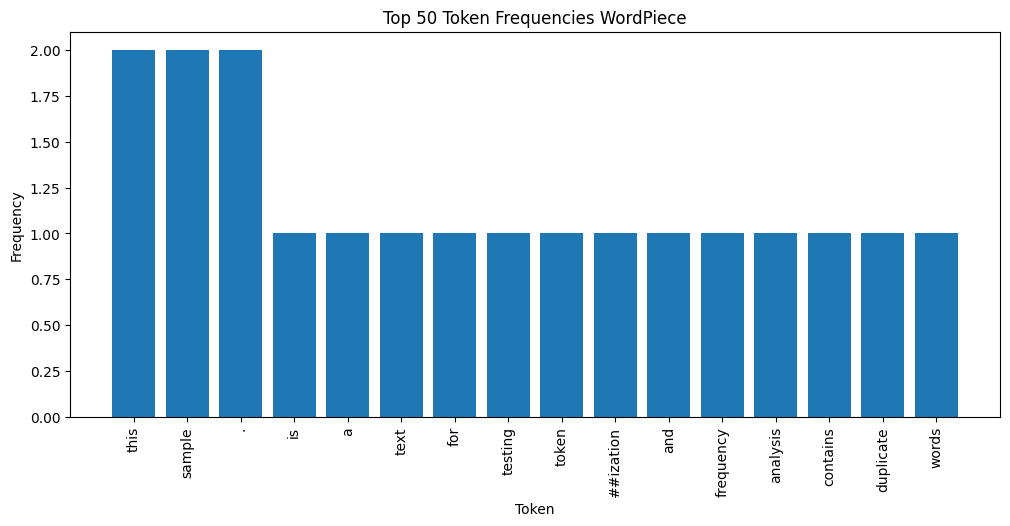

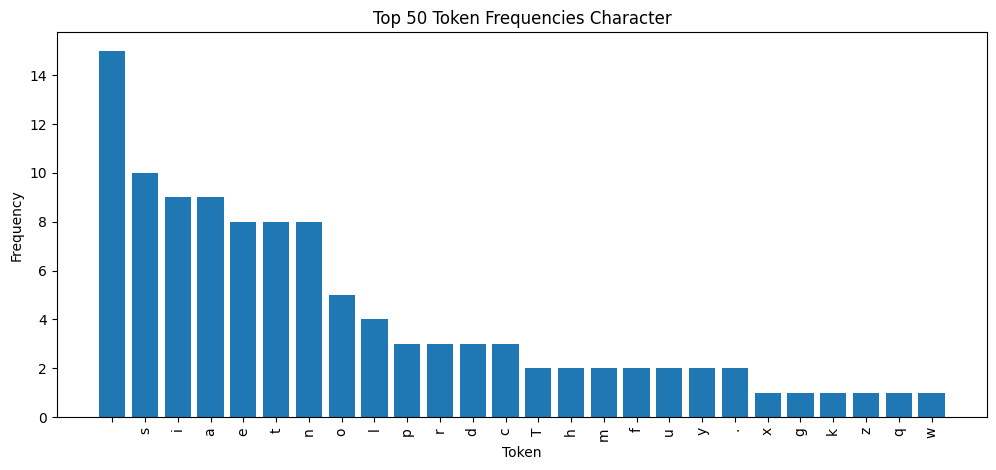

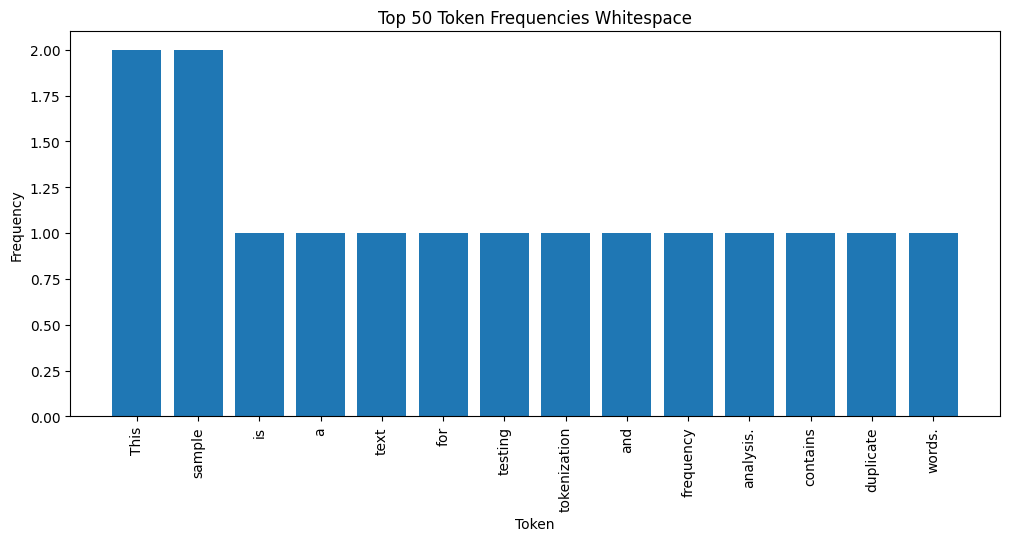

In [14]:
import collections
import matplotlib.pyplot as plt

def analyze_token_distribution(tokens, tokenizer, mode):
    token_counts = collections.Counter(tokens)
    most_common_tokens = token_counts.most_common(50)

    tokens, counts = zip(*most_common_tokens)
    plt.figure(figsize=(12, 5))
    plt.bar(tokens, counts)
    plt.xticks(rotation=90)
    plt.xlabel("Token")
    plt.ylabel("Frequency")
    plt.title(f"Top 50 Token Frequencies {mode}")
    plt.show()

# Example usage
sample_text = "This is a sample text for testing tokenization and frequency analysis. This sample contains duplicate words."
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
analyze_token_distribution(tokenizer.tokenize(sample_text), tokenizer, "WordPiece")
analyze_token_distribution(list(sample_text), tokenizer, "Character")
analyze_token_distribution(sample_text.split(" "), tokenizer, "Whitespace")

Modify the function to support multiple tokenization methods (e.g., whitespace, subword, and character-based tokenization).

---

### Submission
Submit your completed notebook with answers and executed code outputs. Ensure that all model outputs, loss trends, and dataset analyses are included in your submission.